<a href="https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-13-attention-mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 13. Attention Mechanisms

**Book:** *The Mathematics of Natural Language Processing*  
**Chapter:** 13 — Attention Mechanisms  
**Repository:** https://github.com/wanghemath/Book-MathNLP

## Independent-study goals

This lab is designed so that you can study attention even before using a deep-learning library. By the end, you should be able to:

1. explain queries, keys, values, scores, masks, and attention weights;
2. implement scaled dot-product attention from scratch in NumPy;
3. verify every important matrix shape;
4. interpret the attention matrix as a row-stochastic matrix;
5. apply padding masks and causal masks correctly;
6. visualize attention as a token-token heatmap;
7. understand why the scale factor $1/\sqrt{d_k}$ matters;
8. connect attention with nearest-neighbor lookup, kernel smoothing, and sequence modeling.

This notebook intentionally uses small synthetic examples. The point is not to train a large transformer. The point is to understand the mathematical operation that transformer layers use many times.

## 0. Mathematical background

Attention takes three matrices:

$$
Q \in R^{T_q \times d_k}, \qquad
K \in R^{T_k \times d_k}, \qquad
V \in R^{T_k \times d_v}.
$$

The rows of these matrices have the following meanings:

- $q_i$ is a **query**: what position $i$ is looking for;
- $k_j$ is a **key**: what position $j$ advertises;
- $v_j$ is a **value**: the information available at position $j$.

The scaled dot-product attention formula is

$$
Z = A V,
\qquad
A = \operatorname{softmax}_{\text{row}}\left(\frac{QK^T}{\sqrt{d_k}} + M\right),
$$

where $M$ is an optional mask. The matrix $A$ has shape $T_q \times T_k$. Each row of $A$ is a probability vector:

$$
A_{ij} \ge 0,
\qquad
\sum_{j=1}^{T_k} A_{ij}=1.
$$

Therefore, each output row is a weighted average:

$$
z_i = \sum_{j=1}^{T_k} A_{ij} v_j.
$$

A useful phrase to remember is:

> Attention is learned, data-dependent weighted averaging.

## 1. Setup

We will use only NumPy, pandas, and matplotlib. This keeps the lab transparent and Colab-friendly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(7243)

## 2. A tiny sentence and token representations

We need a short sequence. Instead of downloading a data set, we will create a toy sentence and assign each token a small vector.

The input matrix $X$ has one row per token:

$$
X \in R^{T \times d_{\text{model}}}.
$$

In real NLP systems, $X$ usually comes from token embeddings plus positional information. Here we create $X$ by hand so that the geometry is easy to inspect.

In [2]:
tokens = ["the", "student", "studies", "attention", "carefully"]
T = len(tokens)
D_model = 4

# A small hand-designed representation matrix.
# Columns can be loosely read as: determiner-like, noun-like, verb-like, concept/adverb-like.
X = np.array([
    [1.00, 0.05, 0.05, 0.00],  # the
    [0.05, 1.00, 0.10, 0.10],  # student
    [0.05, 0.25, 1.00, 0.10],  # studies
    [0.05, 0.20, 0.35, 1.00],  # attention
    [0.05, 0.10, 0.60, 0.85],  # carefully
])

X_df = pd.DataFrame(X, index=tokens, columns=[f"feature {j}" for j in range(D_model)])
X_df

,feature 0,feature 1,feature 2,feature 3
the,1.00,0.05,0.05,0.00
student,0.05,1.00,0.10,0.10
studies,0.05,0.25,1.00,0.10
attention,0.05,0.20,0.35,1.00
carefully,0.05,0.10,0.60,0.85


### Reflection

Before running attention, look at the rows of $X$.

- Which tokens are close to each other?
- Which tokens are far apart?
- Why might “attention” and “carefully” have related features in this toy example?

## 3. Stable row-wise softmax

The softmax converts arbitrary real scores into a probability vector. For one row $r$, softmax is

$$
\operatorname{softmax}(r)_j = \frac{\exp(r_j)}{\sum_\ell \exp(r_\ell)}.
$$

For numerical stability, we subtract the row maximum before exponentiating:

$$
\operatorname{softmax}(r)_j = \frac{\exp(r_j-c)}{\sum_\ell \exp(r_\ell-c)},
\qquad c = \max_\ell r_\ell.
$$

This does not change the answer, but it prevents overflow when some scores are large.

In [3]:
def row_softmax(S):
    """Stable row-wise softmax for a 2D NumPy array."""
    S = np.asarray(S, dtype=float)
    S_shifted = S - S.max(axis=1, keepdims=True)
    E = np.exp(S_shifted)
    return E / E.sum(axis=1, keepdims=True)

small_scores = np.array([
    [1.0, 2.0, 3.0],
    [1000.0, 1001.0, 1002.0],
    [-5.0, -5.0, -5.0],
])

A_small = row_softmax(small_scores)
print(A_small)
print("Row sums:", A_small.sum(axis=1))

[[0.09  0.245 0.665]
 [0.09  0.245 0.665]
 [0.333 0.333 0.333]]
Row sums: [1. 1. 1.]


### Checkpoint

The second row contains very large numbers. A naive implementation using `np.exp(1002)` may overflow. The stable softmax handles it correctly.

## 4. Dimension checking

Dimension checking is one of the best debugging tools for attention.

If

$$
X \in R^{T \times d_{\text{model}}},
\quad
W_Q,W_K \in R^{d_{\text{model}} \times d_k},
\quad
W_V \in R^{d_{\text{model}} \times d_v},
$$

then

$$
Q=XW_Q \in R^{T \times d_k},
\qquad
K=XW_K \in R^{T \times d_k},
\qquad
V=XW_V \in R^{T \times d_v}.
$$

The score matrix is

$$
QK^T \in R^{T \times T}.
$$

In [4]:
def shape_table(T=5, D_model=4, d_k=3, d_v=2):
    rows = [
        ("X", f"({T}, {D_model})", "input token representations"),
        ("W_Q", f"({D_model}, {d_k})", "query projection"),
        ("W_K", f"({D_model}, {d_k})", "key projection"),
        ("W_V", f"({D_model}, {d_v})", "value projection"),
        ("Q = X W_Q", f"({T}, {d_k})", "queries"),
        ("K = X W_K", f"({T}, {d_k})", "keys"),
        ("V = X W_V", f"({T}, {d_v})", "values"),
        ("S = Q K^T", f"({T}, {T})", "all query-key scores"),
        ("A = row-softmax(S / sqrt(d_k))", f"({T}, {T})", "attention matrix"),
        ("Z = A V", f"({T}, {d_v})", "attention output"),
    ]
    return pd.DataFrame(rows, columns=["object", "shape", "meaning"])

shape_table(T=T, D_model=D_model, d_k=3, d_v=2)

,object,shape,meaning
0,X,"(5, 4)",input token representations
1,W_Q,"(4, 3)",query projection
2,W_K,"(4, 3)",key projection
3,W_V,"(4, 2)",value projection
4,Q = X W_Q,"(5, 3)",queries
5,K = X W_K,"(5, 3)",keys
6,V = X W_V,"(5, 2)",values
7,S = Q K^T,"(5, 5)",all query-key scores
8,A = row-softmax(S / sqrt(d_k)),"(5, 5)",attention matrix
9,Z = A V,"(5, 2)",attention output


## 5. Attention from scratch

Now we implement the complete formula.

The optional `mask` is added to the scaled scores before softmax. Allowed entries usually have mask value $0$. Disallowed entries receive a very negative number such as $-10^9$.

In [5]:
def scaled_dot_product_attention(Q, K, V, mask=None, return_scores=True):
    """Compute scaled dot-product attention.

    Parameters
    ----------
    Q : array, shape (T_q, d_k)
        Query matrix.
    K : array, shape (T_k, d_k)
        Key matrix.
    V : array, shape (T_k, d_v)
        Value matrix.
    mask : array or None, shape (T_q, T_k)
        Additive mask. Use 0 for allowed entries and a large negative value for disallowed entries.
    return_scores : bool
        Whether to return the scaled score matrix.

    Returns
    -------
    Z : array, shape (T_q, d_v)
        Attention output.
    A : array, shape (T_q, T_k)
        Attention matrix.
    scores : array, shape (T_q, T_k)
        Scaled scores after mask addition.
    """
    Q = np.asarray(Q, dtype=float)
    K = np.asarray(K, dtype=float)
    V = np.asarray(V, dtype=float)

    if Q.ndim != 2 or K.ndim != 2 or V.ndim != 2:
        raise ValueError("Q, K, and V must be 2D arrays.")
    if Q.shape[1] != K.shape[1]:
        raise ValueError(f"Q and K must have the same d_k. Got {Q.shape[1]} and {K.shape[1]}.")
    if K.shape[0] != V.shape[0]:
        raise ValueError(f"K and V must have the same number of rows. Got {K.shape[0]} and {V.shape[0]}.")

    d_k = Q.shape[1]
    scores = (Q @ K.T) / np.sqrt(d_k)

    if mask is not None:
        mask = np.asarray(mask, dtype=float)
        if mask.shape != scores.shape:
            raise ValueError(f"mask shape {mask.shape} must match scores shape {scores.shape}.")
        scores = scores + mask

    A = row_softmax(scores)
    Z = A @ V

    if return_scores:
        return Z, A, scores
    return Z, A

## 6. Worked example: $Q=K$

This is the same small structure used in many attention explanations. Since $Q=K$, a token has high similarity with tokens whose vectors point in similar directions.

In [6]:
Q_demo = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
K_demo = Q_demo.copy()
V_demo = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

Z_demo, A_demo, scores_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo)

print("Scaled scores:")
print(scores_demo)
print("\nAttention weights:")
print(A_demo)
print("\nOutput Z:")
print(Z_demo)
print("\nRow sums:", A_demo.sum(axis=1))

Scaled scores:
[[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

Attention weights:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]
 [0.248 0.248 0.503]]

Output Z:
[[0.802 0.599]
 [0.599 0.802]
 [0.752 0.752]]

Row sums: [1. 1. 1.]


### Interpretation

The first query $[1,0]$ is similar to the first key $[1,0]$ and the third key $[1,1]$. Therefore its attention weights are larger on positions 1 and 3 than on position 2.

## 7. Learned projections from $X$

In neural NLP models, $Q$, $K$, and $V$ are not given directly. They are produced by learned matrices:

$$
Q=XW_Q,
\qquad
K=XW_K,
\qquad
V=XW_V.
$$

Here we initialize projection matrices randomly. Since they are random, the attention weights are not meaningful yet, but the computation has the same shape as a real model.

In [7]:
d_k = 3
d_v = 2

W_Q = rng.normal(scale=0.5, size=(D_model, d_k))
W_K = rng.normal(scale=0.5, size=(D_model, d_k))
W_V = rng.normal(scale=0.5, size=(D_model, d_v))

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
Z, A, scores = scaled_dot_product_attention(Q, K, V)

print("X:", X.shape)
print("W_Q:", W_Q.shape, "W_K:", W_K.shape, "W_V:", W_V.shape)
print("Q:", Q.shape, "K:", K.shape, "V:", V.shape)
print("scores:", scores.shape, "A:", A.shape, "Z:", Z.shape)
print("Row sums of A:", A.sum(axis=1))

X: (5, 4)
W_Q: (4, 3) W_K: (4, 3) W_V: (4, 2)
Q: (5, 3) K: (5, 3) V: (5, 2)
scores: (5, 5) A: (5, 5) Z: (5, 2)
Row sums of A: [1. 1. 1. 1. 1.]


## 8. Attention heatmap

An attention heatmap displays $A_{ij}$, the amount of attention from query token $i$ to key/value token $j$.

Rows are query tokens. Columns are key/value tokens.

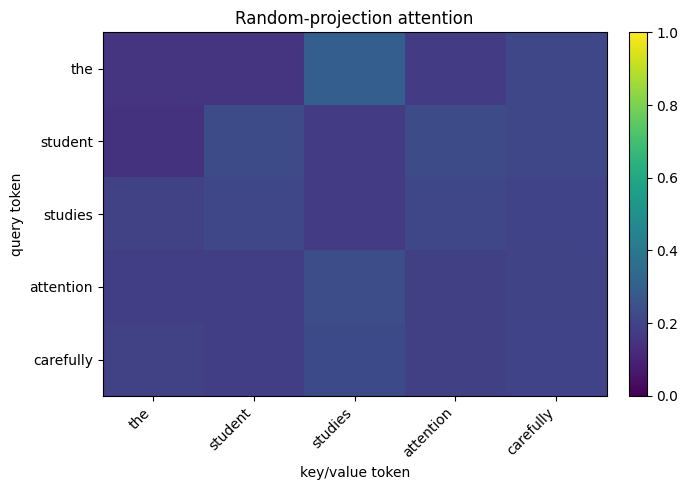

In [8]:
def plot_attention(A, tokens_q, tokens_k=None, title="Attention matrix"):
    if tokens_k is None:
        tokens_k = tokens_q
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(A, aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens_k)))
    ax.set_xticklabels(tokens_k, rotation=45, ha="right")
    ax.set_yticks(range(len(tokens_q)))
    ax.set_yticklabels(tokens_q)
    ax.set_xlabel("key/value token")
    ax.set_ylabel("query token")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_attention(A, tokens, title="Random-projection attention")

### Caution about interpretation

Attention weights show an internal information-routing pattern. They are useful for inspection, but they are not automatically a complete causal explanation of a model prediction.

## 9. Why divide by $\sqrt{d_k}$?

If coordinates of $q$ and $k$ have mean $0$ and variance about $1$, then the dot product

$$
q^T k = \sum_{r=1}^{d_k} q_r k_r
$$

has variance that grows roughly like $d_k$. Dividing by $\sqrt{d_k}$ keeps score magnitudes more stable.

We can see the effect with simulation.

In [9]:
def simulate_dot_products(d_k_values, n=20_000):
    rows = []
    for dk in d_k_values:
        q = rng.normal(size=(n, dk))
        k = rng.normal(size=(n, dk))
        dots = np.sum(q * k, axis=1)
        scaled = dots / np.sqrt(dk)
        rows.append({
            "d_k": dk,
            "std(q dot k)": np.std(dots),
            "std((q dot k)/sqrt(d_k))": np.std(scaled),
        })
    return pd.DataFrame(rows)

scale_df = simulate_dot_products([2, 4, 8, 16, 32, 64, 128])
scale_df

,d_k,std(q dot k),std((q dot k)/sqrt(d_k))
0,2,1.431475,1.012206
1,4,1.994965,0.997482
2,8,2.803200,0.991081
3,16,4.003466,1.000867
4,32,5.626825,0.994692
5,64,7.951397,0.993925
6,128,11.387274,1.006502


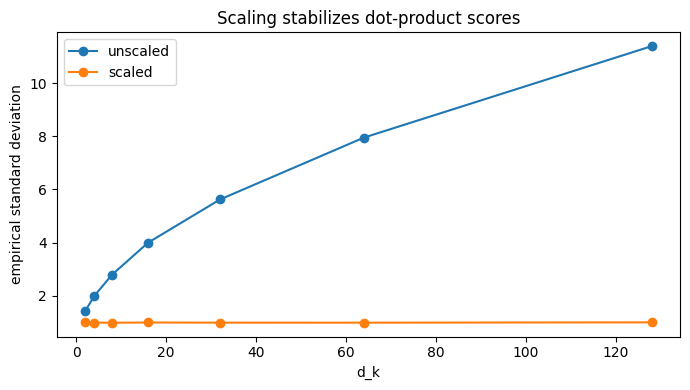

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(scale_df["d_k"], scale_df["std(q dot k)"], marker="o", label="unscaled")
plt.plot(scale_df["d_k"], scale_df["std((q dot k)/sqrt(d_k))"], marker="o", label="scaled")
plt.xlabel("d_k")
plt.ylabel("empirical standard deviation")
plt.title("Scaling stabilizes dot-product scores")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Scale, entropy, and sharpness

When scores are multiplied by a large number, the softmax becomes sharper. When scores are multiplied by a small number, attention becomes more diffuse.

A useful measure is row entropy:

$$
H(a_i) = -\sum_j a_{ij}\log(a_{ij}).
$$

Higher entropy means more diffuse attention. Lower entropy means more concentrated attention.

In [11]:
def row_entropy(A, eps=1e-12):
    A_safe = np.clip(A, eps, 1.0)
    return -np.sum(A_safe * np.log(A_safe), axis=1)

base_scores = Q @ K.T / np.sqrt(d_k)
scales = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rows = []
for s in scales:
    A_s = row_softmax(s * base_scores)
    rows.append({
        "score scale": s,
        "average row entropy": row_entropy(A_s).mean(),
        "maximum attention weight": A_s.max(axis=1).mean(),
    })

entropy_df = pd.DataFrame(rows)
entropy_df

,score scale,average row entropy,maximum attention weight
0,0.25,1.608716,0.209868
1,0.50,1.606521,0.220109
2,1.00,1.597581,0.241614
3,2.00,1.561683,0.287691
4,4.00,1.435601,0.381230
5,8.00,1.156896,0.524437


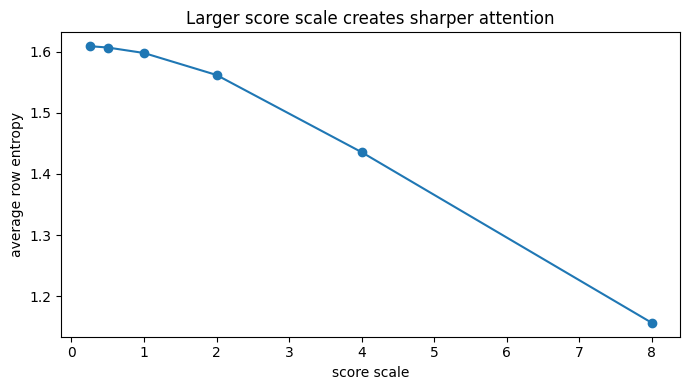

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(entropy_df["score scale"], entropy_df["average row entropy"], marker="o")
plt.xlabel("score scale")
plt.ylabel("average row entropy")
plt.title("Larger score scale creates sharper attention")
plt.tight_layout()
plt.show()

## 11. Causal masks

For autoregressive language modeling, position $i$ should not attend to future positions $j>i$. The causal mask is

$$
M_{ij} =
\begin{cases}
0, & j \le i, \\
-10^9, & j > i.
\end{cases}
$$

This mask is added before softmax.

In [13]:
def causal_mask(T_q, T_k=None, large_negative=-1e9):
    if T_k is None:
        T_k = T_q
    mask = np.zeros((T_q, T_k))
    for i in range(T_q):
        for j in range(T_k):
            if j > i:
                mask[i, j] = large_negative
    return mask

M_causal = causal_mask(T)
Z_causal, A_causal, scores_causal = scaled_dot_product_attention(Q, K, V, mask=M_causal)

pd.DataFrame(A_causal, index=tokens, columns=tokens)

,the,student,studies,attention,carefully
the,1.000000,0.000000,0.000000,0.000000,0.000000
student,0.385150,0.614850,0.000000,0.000000,0.000000
studies,0.333945,0.362927,0.303128,0.000000,0.000000
attention,0.231300,0.231599,0.297617,0.239485,0.000000
carefully,0.194254,0.186467,0.225456,0.191352,0.202471


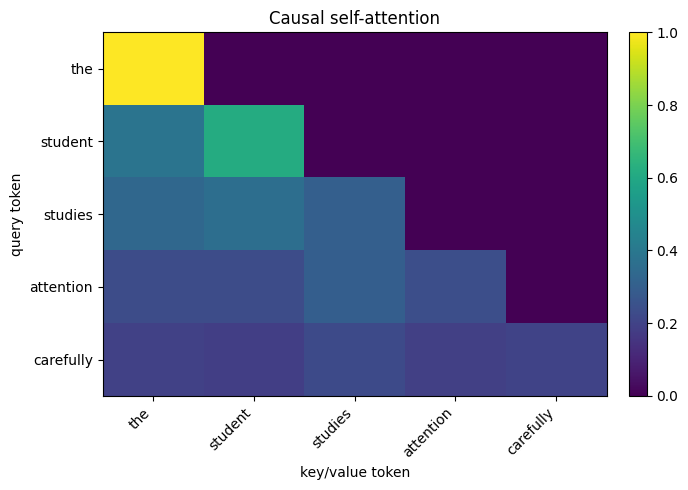

Largest attention weight on a future token: 0.0
Row sums: [1. 1. 1. 1. 1.]


In [14]:
plot_attention(A_causal, tokens, title="Causal self-attention")
print("Largest attention weight on a future token:", np.triu(A_causal, k=1).max())
print("Row sums:", A_causal.sum(axis=1))

### Checkpoint

The upper triangular part should be approximately zero. This confirms that no token attends to future tokens.

## 12. Padding masks

In batched NLP, sequences often have different lengths. We add padding tokens so all sequences have the same length, but real tokens should not attend to padding positions.

A padding mask blocks selected key/value columns.

In [15]:
padded_tokens = ["the", "student", "studies", "<pad>", "<pad>"]
valid_key = np.array([1, 1, 1, 0, 0], dtype=bool)

# Use the same Q, K, V shapes for demonstration.
M_padding = np.zeros((T, T))
M_padding[:, ~valid_key] = -1e9

Z_pad, A_pad, scores_pad = scaled_dot_product_attention(Q, K, V, mask=M_padding)

pd.DataFrame(A_pad, index=padded_tokens, columns=padded_tokens)

,the,student,studies,<pad>,<pad>
the,0.254766,0.252331,0.492904,0.0,0.0
student,0.262032,0.418306,0.319661,0.0,0.0
studies,0.333945,0.362927,0.303128,0.0,0.0
<pad>,0.304136,0.304528,0.391336,0.0,0.0
<pad>,0.320457,0.307612,0.371931,0.0,0.0


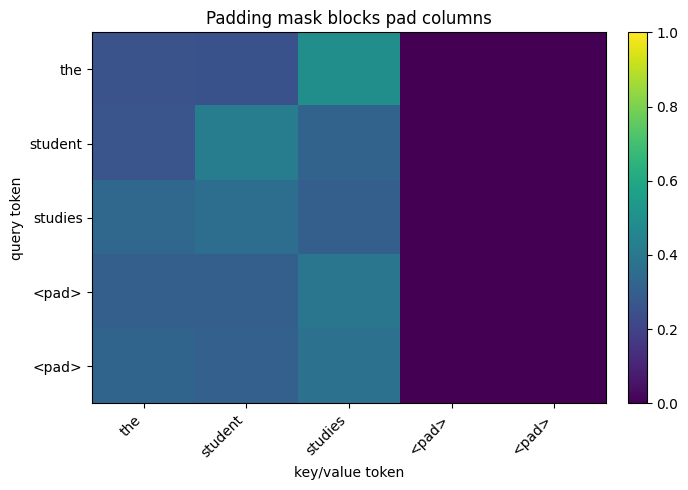

Attention assigned to padding columns: 0.0
Row sums: [1. 1. 1. 1. 1.]


In [16]:
plot_attention(A_pad, padded_tokens, title="Padding mask blocks pad columns")
print("Attention assigned to padding columns:", A_pad[:, ~valid_key].sum())
print("Row sums:", A_pad.sum(axis=1))

### Important detail

A padding mask usually blocks padding **keys and values**. In many implementations, padding query positions may also be ignored later by the loss function.

## 13. Attention as soft nearest-neighbor lookup

Attention can be compared with nearest-neighbor lookup.

- Nearest-neighbor lookup chooses one item.
- Attention creates a soft weighted average of many items.

If the softmax is very sharp, attention behaves more like hard lookup. If the softmax is diffuse, attention behaves more like kernel smoothing.

In [17]:
def nearest_neighbor_lookup(Q, K, V):
    scores = Q @ K.T
    indices = np.argmax(scores, axis=1)
    return V[indices], indices, scores

V_hard, nn_indices, nn_scores = nearest_neighbor_lookup(Q, K, V)

comparison = pd.DataFrame({
    "query token": tokens,
    "nearest key token": [tokens[j] for j in nn_indices],
})
comparison

,query token,nearest key token
0,the,studies
1,student,attention
2,studies,student
3,attention,studies
4,carefully,studies


Average maximum attention weight with scale 20: 0.7275349194799576
Norm difference between sharp attention output and hard lookup output: 0.3562674701946442


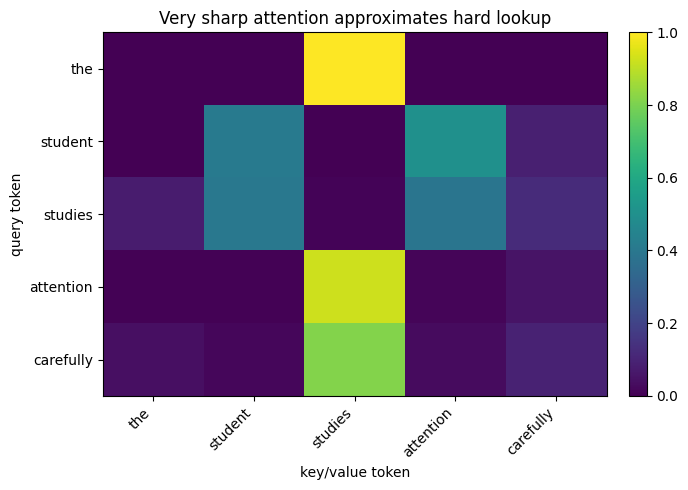

In [18]:
A_very_sharp = row_softmax(20.0 * base_scores)
Z_soft_sharp = A_very_sharp @ V

print("Average maximum attention weight with scale 20:", A_very_sharp.max(axis=1).mean())
print("Norm difference between sharp attention output and hard lookup output:", np.linalg.norm(Z_soft_sharp - V_hard))
plot_attention(A_very_sharp, tokens, title="Very sharp attention approximates hard lookup")

## 14. Manually designed query-key behavior

Random projections are hard to interpret. To understand the mechanism, we can choose simple query and key vectors manually.

Goal: make the query token `studies` attend strongly to the key token `attention`.

In [19]:
# Two-dimensional query/key space.
Q_manual = np.zeros((T, 2))
K_manual = np.zeros((T, 2))

# Most tokens have small generic vectors.
Q_manual[:] = np.array([0.1, 0.1])
K_manual[:] = np.array([0.1, 0.1])

# Make query at "studies" point toward a special direction.
studies_idx = tokens.index("studies")
attention_idx = tokens.index("attention")
Q_manual[studies_idx] = np.array([3.0, 0.0])

# Make key at "attention" advertise that same direction.
K_manual[attention_idx] = np.array([3.0, 0.0])

# Use simple value vectors based on X for readability.
V_manual = X[:, :2]

Z_manual, A_manual, scores_manual = scaled_dot_product_attention(Q_manual, K_manual, V_manual)

pd.DataFrame(A_manual, index=tokens, columns=tokens)

,the,student,studies,attention,carefully
the,0.191609,0.191609,0.191609,0.233562,0.191609
student,0.191609,0.191609,0.191609,0.233562,0.191609
studies,0.002112,0.002112,0.002112,0.991554,0.002112
attention,0.191609,0.191609,0.191609,0.233562,0.191609
carefully,0.191609,0.191609,0.191609,0.233562,0.191609


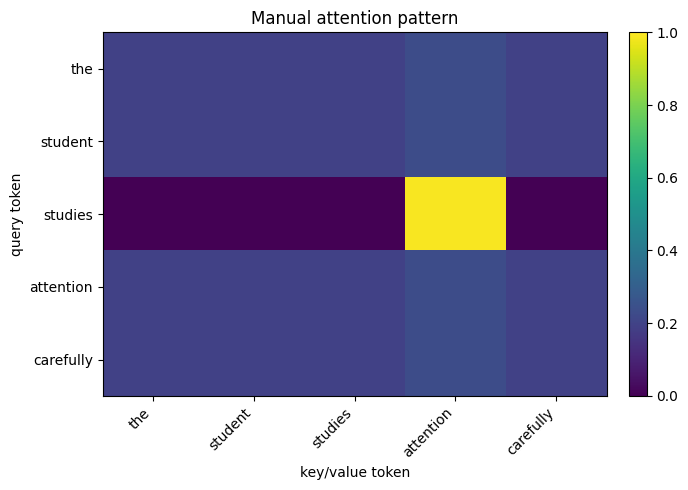

For query token 'studies', most-attended key token: attention
Attention row for 'studies':
the          0.002112
student      0.002112
studies      0.002112
attention    0.991554
carefully    0.002112
dtype: float64


In [20]:
plot_attention(A_manual, tokens, title="Manual attention pattern")
print("For query token 'studies', most-attended key token:", tokens[np.argmax(A_manual[studies_idx])])
print("Attention row for 'studies':")
print(pd.Series(A_manual[studies_idx], index=tokens))

### Exercise idea

Modify the vectors so that `carefully` attends strongly to `studies`. Then rerun the attention heatmap.

## 15. Softmax Jacobian and gradient intuition

For a softmax vector $a=\operatorname{softmax}(r)$, the Jacobian is

$$
J_{j\ell}=\frac{\partial a_j}{\partial r_\ell}=a_j(\delta_{j\ell}-a_\ell).
$$

When attention is extremely peaked, many entries of this Jacobian become small. This is one reason very large unscaled scores can make optimization less stable.

In [21]:
def softmax_jacobian(a):
    a = np.asarray(a, dtype=float)
    return np.diag(a) - np.outer(a, a)

rows = []
for s in [0.5, 1.0, 2.0, 5.0, 10.0]:
    row = row_softmax(np.array([[s, 0.0, -s]]))[0]
    J = softmax_jacobian(row)
    rows.append({
        "score scale": s,
        "softmax vector": np.round(row, 4),
        "Jacobian Frobenius norm": np.linalg.norm(J),
        "entropy": -np.sum(row * np.log(row + 1e-12)),
    })

pd.DataFrame(rows)

,score scale,softmax vector,Jacobian Frobenius norm,entropy
0,0.5,"[0.5065, 0.3072, 0.1863]",0.451152,1.020191
1,1.0,"[0.6652, 0.2447, 0.09]",0.389390,0.832396
2,2.0,"[0.8668, 0.1173, 0.0159]",0.212980,0.441057
3,5.0,"[0.9933, 0.0067, 0.0]",0.013318,0.040674
4,10.0,"[1.0, 0.0, 0.0]",0.000091,0.000499


## 16. Multi-head attention preview

A single attention head has one query-key comparison geometry. Multi-head attention uses several heads in parallel:

$$
\operatorname{head}_h = \operatorname{Attention}(XW_Q^{(h)}, XW_K^{(h)}, XW_V^{(h)}).
$$

The heads are concatenated:

$$
\operatorname{Concat}(\operatorname{head}_1, \ldots, \operatorname{head}_H).
$$

The next chapters study this in more detail. Here we only check the shapes.

In [22]:
def one_attention_head(X, d_k=2, d_v=2, seed=0):
    local_rng = np.random.default_rng(seed)
    D = X.shape[1]
    WQ = local_rng.normal(scale=0.4, size=(D, d_k))
    WK = local_rng.normal(scale=0.4, size=(D, d_k))
    WV = local_rng.normal(scale=0.4, size=(D, d_v))
    Qh, Kh, Vh = X @ WQ, X @ WK, X @ WV
    Zh, Ah, Sh = scaled_dot_product_attention(Qh, Kh, Vh)
    return Zh, Ah

head_outputs = []
head_weights = []
for h in range(3):
    Zh, Ah = one_attention_head(X, d_k=2, d_v=2, seed=100 + h)
    head_outputs.append(Zh)
    head_weights.append(Ah)

multi_head_concat = np.concatenate(head_outputs, axis=1)
print("Each head output shape:", head_outputs[0].shape)
print("Concatenated output shape:", multi_head_concat.shape)

Each head output shape: (5, 2)
Concatenated output shape: (5, 6)


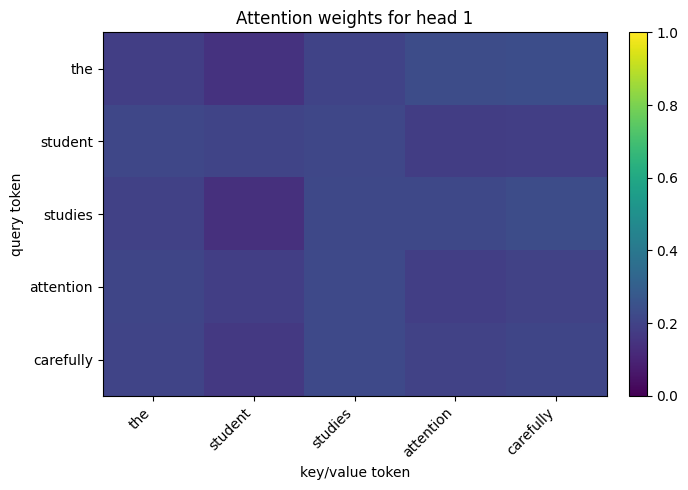

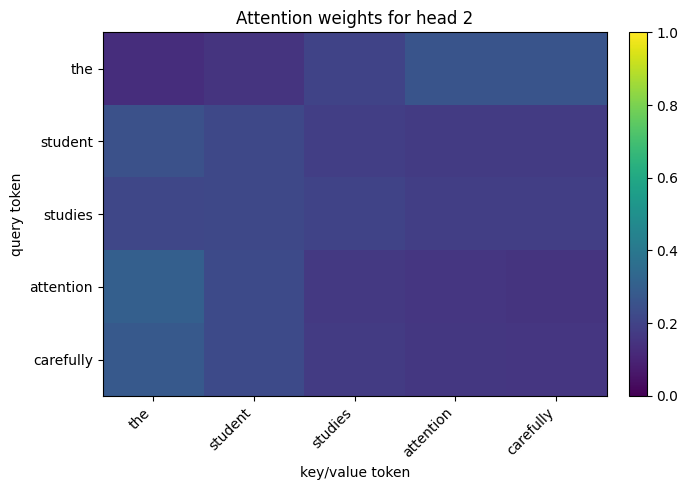

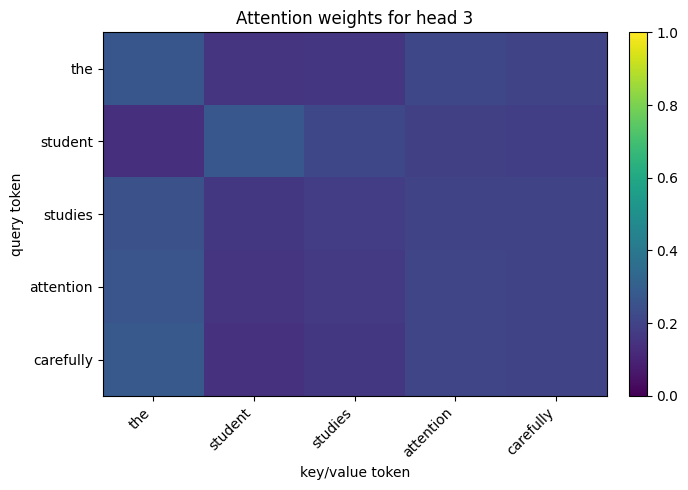

In [23]:
for h, Ah in enumerate(head_weights, start=1):
    plot_attention(Ah, tokens, title=f"Attention weights for head {h}")

## 17. Mini experiment: compare unmasked and causal attention

Let us place the two matrices side by side as data frames and compare their row entropies.

In [24]:
comparison_entropy = pd.DataFrame({
    "token": tokens,
    "unmasked entropy": row_entropy(A),
    "causal entropy": row_entropy(A_causal),
    "unmasked max weight": A.max(axis=1),
    "causal max weight": A_causal.max(axis=1),
})
comparison_entropy

,token,unmasked entropy,causal entropy,unmasked max weight,causal max weight
0,the,1.574658,1.105241e-10,0.299658,1.000000
1,student,1.594141,6.665290e-01,0.233479,0.614850
2,studies,1.607321,1.095923e+00,0.212907,0.362927
3,attention,1.604660,1.380387e+00,0.236568,0.297617
4,carefully,1.607126,1.607126e+00,0.225456,0.225456


### Interpretation question

Why is the first row of causal attention always concentrated on the first token only?

Because the first token has no previous tokens. Under a causal mask, it is allowed to attend only to itself.

## 18. Practice exercises

Complete these exercises by editing or adding code cells below.

### Exercise 1: Dimension check

Suppose $T=12$, $d_{\text{model}}=64$, $d_k=16$, and $d_v=20$. Write the shapes of

$$
X, W_Q, W_K, W_V, Q, K, V, QK^T, A, Z.
$$

Use the `shape_table` function to check your answer.

### Exercise 2: Row-stochastic verification

Generate random $Q$, $K$, and $V$. Compute attention. Verify numerically that each row of $A$ sums to $1$ and that all entries are nonnegative.

### Exercise 3: Causal masking

For $T=7$, create a causal mask. Verify that the upper triangular part of the resulting attention matrix is zero up to numerical precision.

### Exercise 4: Scaling

Repeat the entropy experiment for scales from $0.1$ to $10$. Explain how the maximum attention weight changes.

### Exercise 5: Manual routing

Design query and key vectors so that one token attends strongly to a chosen earlier token. Visualize the result.

In [25]:
# Exercise 1 starter
shape_table(T=12, D_model=64, d_k=16, d_v=20)

,object,shape,meaning
0,X,"(12, 64)",input token representations
1,W_Q,"(64, 16)",query projection
2,W_K,"(64, 16)",key projection
3,W_V,"(64, 20)",value projection
4,Q = X W_Q,"(12, 16)",queries
5,K = X W_K,"(12, 16)",keys
6,V = X W_V,"(12, 20)",values
7,S = Q K^T,"(12, 12)",all query-key scores
8,A = row-softmax(S / sqrt(d_k)),"(12, 12)",attention matrix
9,Z = A V,"(12, 20)",attention output


In [26]:
# Exercise 2 starter
Q_ex = rng.normal(size=(6, 4))
K_ex = rng.normal(size=(6, 4))
V_ex = rng.normal(size=(6, 3))
Z_ex, A_ex, scores_ex = scaled_dot_product_attention(Q_ex, K_ex, V_ex)

print("All entries nonnegative:", np.all(A_ex >= 0))
print("Row sums close to 1:", np.allclose(A_ex.sum(axis=1), 1.0))

All entries nonnegative: True
Row sums close to 1: True


## 19. Mini-project

Build a small attention visualizer for a short sentence of your choice.

Your report should include:

1. the sentence and token list;
2. the matrices $Q$, $K$, and $V$ or the projection matrices $W_Q$, $W_K$, and $W_V$;
3. the scaled score matrix;
4. the attention matrix;
5. a heatmap visualization;
6. a comparison of unmasked and causal attention;
7. a short discussion of how changing the score scale changes entropy;
8. a careful statement about what attention weights can and cannot explain.

Optional extension: create two different attention heads and compare their heatmaps.

## 20. AI-assisted learning prompts

Use an AI tool as a mathematical critic, not as an authority. Try prompts such as:

### Prompt A: dimension debugging

> I have $X$ with shape `(T, D)`, $W_Q$ with shape `(D, d_k)`, $W_K$ with shape `(D, d_k)`, and $W_V$ with shape `(D, d_v)`. Check the shapes in scaled dot-product attention and identify where shape errors usually occur.

### Prompt B: mask debugging

> I implemented a causal mask for self-attention. What numerical checks should I run to verify that future positions have zero attention weight?

### Prompt C: interpretation critique

> Explain why attention weights are useful for inspection but are not automatically a complete causal explanation of a transformer prediction.

After receiving an answer, verify it using the code in this notebook.

## 21. Summary

The attention mechanism is built from a few linear algebra operations:

$$
Q=XW_Q, \qquad K=XW_K, \qquad V=XW_V,
$$

$$
A = \operatorname{softmax}_{\text{row}}\left(\frac{QK^T}{\sqrt{d_k}} + M\right),
\qquad
Z=AV.
$$

The key ideas are:

- $QK^T$ compares every query with every key;
- row-wise softmax turns scores into probability weights;
- $AV$ forms weighted averages of value vectors;
- masks change which positions are allowed to receive attention;
- the scale $1/\sqrt{d_k}$ stabilizes score magnitudes;
- attention is adaptive because $A$ depends on the input sequence.